# 30c. Capability-Based Agent Security

**Tier:** Production & Safety
**Estimated time:** 55 minutes
**Prerequisites:** 19 (Agent Loop), 30 (Security & Guardrails), 30b (Human-in-the-Loop)
**Priority:** 🔴 Crucial — notebook 30 taught you to *detect and refuse* bad actions; this teaches you to make them **structurally impossible**. When (not if) the model is fooled by a prompt injection, capabilities are the layer that still holds. *If skipped, revisit when:* any agent you ship can delete, spend, push, or send — i.e. holds an irreversible tool.
**Source material:** The Sovereign Imperia Citadel (`services/authority/` — `fasces` capability tokens, `lease`, `pomerium`, `intercessio`), https://github.com/Hvuj/The-Soverign-Imperia-citadel

## What You'll Learn
- Why "tell the model not to" fails, and how **capabilities** move the guarantee from the prompt to the runtime
- Signed, tamper-evident **capability tokens** with a rods (reversible) / axe (irreversible) split
- **Attenuation** (a delegate can only ever drop powers), **TTL leases** (no grant is forever), and **zone policy** (strip dangerous powers inside protected paths)
- A **dual-uncorrelated-validator gate** for irreversible acts, and wiring all of it into a notebook-19-style agent loop so a prompt injection is blocked *structurally*

## Why This Matters
Notebook 30's lethal trifecta showed that once an agent reads untrusted content and holds a dangerous tool, "just refuse" is not a security boundary — the model can be talked out of it. Capability-based security is how real systems make the boundary hold anyway: the agent literally does not possess an unforgeable token granting `DELETE`, so no amount of clever injection can make it delete. The guarantee lives in the runtime, not in the model's good behaviour.

## The keycard, not the polite note

Two ways to stop a hotel guest from entering the wine cellar:

- **The polite note:** "Please don't go in the cellar." This is a **prompt-level** guardrail — *"you are a helpful assistant, never delete files."* It works until someone (or an injected instruction) talks the guest into ignoring it.
- **The keycard:** the guest's card physically won't open the cellar door. It doesn't matter how they're persuaded, threatened, or tricked — the door stays shut. This is a **capability**: an unforgeable token that grants *specific* powers and nothing else.

Capability security flips the default. Instead of "you can do anything, please avoid the bad things," it's **"you can do exactly the things your token grants, and there is no path to anything else."** The four ideas from Citadel's `authority/` package:

1. **Fasces (capability tokens).** A signed bitmask. Low bits are **rods** — reversible actions (write a file, apply a patch). High bits are the **axe** — irreversible actions (delete, force-push, drop a table). An HMAC signs the token so tampering is detectable.
2. **Attenuation.** When an officer delegates to a worker, the worker's mask is `parent AND requested` — it can only ever *drop* bits, never gain them. A sub-agent can't out-rank its creator.
3. **Leases.** Every grant carries a TTL. A reaper collects expired grants. No authority is forever, so a leaked token stops working on its own.
4. **Zone policy (pomerium) + dual-validator gate.** Inside protected paths the axe is stripped for *everyone*. And an irreversible act needs **two independent PASS verdicts from *different* validator families** — because a second copy of the same model shares its blind spots.

All of this is a few dozen lines of standard-library Python. Let's build it.

In [1]:
# Fully offline + deterministic — no API key required for this notebook.
import hmac, hashlib, time, heapq, itertools
from dataclasses import dataclass, replace

# A per-process secret the runtime uses to sign capability tokens. In production
# this lives in a secrets manager; the agent never sees it.
RUNTIME_KEY = b"demo-runtime-signing-key-not-a-real-secret"
print("Capability runtime ready (stdlib only).")

Capability runtime ready (stdlib only).


## Part 1 — Signed capability tokens (rods vs. axe)

Powers are bits in an integer. **Rods** (reversible) sit in the low bits; the **axe** (irreversible) sits in the high bits. A token is the mask plus an HMAC over all its fields — change any field and the signature no longer verifies, so tokens are **tamper-evident**. `permitted()` is a single unexpired-check + signature-check + bitwise AND.

In [2]:
# --- Reversible "rod" powers (low bits) ---
WRITE_FILE  = 1 << 0
APPLY_PATCH = 1 << 1
READ_FILE   = 1 << 2

# --- Irreversible "axe" powers (high bits) ---
AXE_CLASS   = 0xFFFF_0000_0000_0000   # mask selecting all axe bits
DELETE_PATH = 1 << 48
FORCE_PUSH  = 1 << 49
SEND_EMAIL  = 1 << 50   # exfiltration channel (leg 3 of the lethal trifecta)

@dataclass(frozen=True, slots=True)
class Fasces:
    holder: str        # who holds it
    mask: int          # the granted powers
    lease_id: str      # which lease keeps it alive
    expiry: float      # unix time; 0 = no expiry
    signature: str     # HMAC binding all of the above

def _canonical(holder, mask, lease_id, expiry):
    return f"{holder}|{mask}|{lease_id}|{expiry}".encode()

def sign_token(holder, mask, lease_id, expiry, *, key=RUNTIME_KEY):
    sig = hmac.new(key, _canonical(holder, mask, lease_id, expiry), hashlib.sha256).hexdigest()
    return Fasces(holder, mask, lease_id, expiry, sig)

def verify_token(tok, *, key=RUNTIME_KEY):
    expected = hmac.new(key, _canonical(tok.holder, tok.mask, tok.lease_id, tok.expiry), hashlib.sha256).hexdigest()
    return hmac.compare_digest(expected, tok.signature)

def permitted(required, tok, *, in_protected_zone=False, key=RUNTIME_KEY, now=None):
    # O(1) check: unexpired, signature valid, and the effective mask (axe removed
    # inside a protected zone) grants every required bit.
    current = time.time() if now is None else now
    if tok.expiry and current >= tok.expiry:
        return False
    if not verify_token(tok, key=key):
        return False
    effective = tok.mask & ~AXE_CLASS if in_protected_zone else tok.mask
    return (required & effective) == required

# A root token that holds everything (rods + axe).
root = sign_token("root", WRITE_FILE | APPLY_PATCH | READ_FILE | DELETE_PATH | FORCE_PUSH | SEND_EMAIL, "lease-root", 0)
print("root can WRITE_FILE :", permitted(WRITE_FILE, root))
print("root can DELETE_PATH:", permitted(DELETE_PATH, root))
print("token signature valid:", verify_token(root))

root can WRITE_FILE : True
root can DELETE_PATH: True
token signature valid: True


## Part 2 — Attenuation: a delegate can only lose power

When root spins up a worker sub-agent, the worker asks for a set of powers. It receives `parent AND requested` — so even if it *asks* for the axe, it only gets bits the parent already had *and* chose to pass down. A sub-agent can never escalate above its creator. This is the single most important invariant: it makes a multi-agent system's blast radius shrink, never grow, as you go down the tree.

In [3]:
def attenuate(parent_mask, requested_mask):
    # Delegation drops bits only — never adds them.
    return parent_mask & requested_mask

# The worker only needs to read and write. We deliberately grant rods only.
worker_request = WRITE_FILE | READ_FILE
worker_mask = attenuate(root.mask, worker_request)
worker = sign_token("worker", worker_mask, "lease-worker", 0)

print("worker can WRITE_FILE :", permitted(WRITE_FILE, worker))
print("worker can DELETE_PATH:", permitted(DELETE_PATH, worker), " <- axe never delegated")

# A malicious/confused worker tries to grant ITSELF the axe by asking for everything:
greedy = attenuate(worker.mask, DELETE_PATH | FORCE_PUSH | SEND_EMAIL)
print("greedy re-request yields mask:", greedy, "(0 = nothing gained)")

# Tampering: flip the mask to add DELETE_PATH, keep the old signature.
forged = replace(worker, mask=worker.mask | DELETE_PATH)
print("forged token verifies:", verify_token(forged), " <- HMAC catches the edit")
print("forged token permitted to DELETE:", permitted(DELETE_PATH, forged))

worker can WRITE_FILE : True
worker can DELETE_PATH: False  <- axe never delegated
greedy re-request yields mask: 0 (0 = nothing gained)
forged token verifies: False  <- HMAC catches the edit
forged token permitted to DELETE: False


## Part 3 — Leases: no grant is forever

Every token references a **lease** with a TTL. A `LeaseReaper` keeps a min-heap keyed by expiry, so finding the next grant to die is O(1) and granting is O(log L). `is_valid` is O(1). The point: a token that leaks, or a worker that hangs, stops being dangerous on its own — the grant simply expires. `permitted()` above already refuses an expired token; here we tie tokens to a live lease registry.

In [4]:
@dataclass(frozen=True, slots=True)
class Lease:
    lease_id: str
    subject: str
    expiry: float

class LeaseReaper:
    def __init__(self):
        self._heap = []                 # (expiry, counter, Lease)
        self._leases = {}
        self._revoked = set()
        self._counter = itertools.count()
    def grant(self, lease_id, subject, ttl_seconds, *, now=None):
        current = time.time() if now is None else now
        lease = Lease(lease_id, subject, current + ttl_seconds)
        self._leases[lease_id] = lease
        self._revoked.discard(lease_id)
        heapq.heappush(self._heap, (lease.expiry, next(self._counter), lease))
        return lease
    def revoke(self, lease_id):
        self._revoked.add(lease_id)
    def is_valid(self, lease_id, *, now=None):
        if lease_id in self._revoked:
            return False
        lease = self._leases.get(lease_id)
        return lease is not None and (time.time() if now is None else now) < lease.expiry
    def reap(self, *, now=None):
        current = time.time() if now is None else now
        dead = []
        while self._heap and (self._heap[0][0] <= current or self._heap[0][2].lease_id in self._revoked):
            _, _, lease = heapq.heappop(self._heap)
            self._leases.pop(lease.lease_id, None)
            dead.append(lease)
        return dead

reaper = LeaseReaper()
t = 1000.0
reaper.grant("lease-worker", "worker", ttl_seconds=30, now=t)
print("valid at t+10s :", reaper.is_valid("lease-worker", now=t + 10))
print("valid at t+31s :", reaper.is_valid("lease-worker", now=t + 31), " <- expired on its own")
print("reaped at t+31s:", [l.subject for l in reaper.reap(now=t + 31)])

# Revocation is immediate (e.g. an operator kills a runaway worker).
reaper.grant("lease-x", "worker2", ttl_seconds=999, now=t)
reaper.revoke("lease-x")
print("revoked lease valid:", reaper.is_valid("lease-x", now=t + 1))

valid at t+10s : True
valid at t+31s : False  <- expired on its own
reaped at t+31s: ['worker']
revoked lease valid: False


## Part 4 — Zone policy + the dual-uncorrelated-validator gate

Two final constraints that bind *even the root*:

- **Pomerium (zone policy).** Inside a protected path (say `secrets/` or `prod/`), the axe is stripped for *everyone* — the emperor may not wield the axe within the wall. We already wired this into `permitted(in_protected_zone=True)`.
- **Intercessio (dual gate).** An irreversible act requires **two PASS verdicts from *different* validator families**. A second instance of the same model shares its blind spots, so it isn't an independent check. Two `gpt`-family validators = not a gate; one `gpt` + one `claude` = a gate.

In [5]:
# Zone policy: even root cannot use the axe inside a protected zone.
print("root DELETE in normal zone   :", permitted(DELETE_PATH, root, in_protected_zone=False))
print("root DELETE in protected zone:", permitted(DELETE_PATH, root, in_protected_zone=True), " <- axe stripped")

@dataclass(frozen=True, slots=True)
class Verdict:
    family: str      # e.g. "claude", "gpt", "gemini"
    passed: bool

def dual_gate(verdicts):
    # An axe-class op is allowed only if >=2 PASS verdicts come from DISTINCT families.
    passing_families = {v.family for v in verdicts if v.passed}
    return len(passing_families) >= 2

print("gate [claude PASS, claude PASS] :", dual_gate([Verdict("claude", True), Verdict("claude", True)]), " <- same family, not independent")
print("gate [claude PASS, gpt PASS]    :", dual_gate([Verdict("claude", True), Verdict("gpt", True)]))
print("gate [claude PASS, gpt FAIL]    :", dual_gate([Verdict("claude", True), Verdict("gpt", False)]))

root DELETE in normal zone   : True
root DELETE in protected zone: False  <- axe stripped
gate [claude PASS, claude PASS] : False  <- same family, not independent
gate [claude PASS, gpt PASS]    : True
gate [claude PASS, gpt FAIL]    : False


## Part 5 — Putting it together: a capability-guarded agent loop

Now the payoff, tied straight back to notebook 30's lethal-trifecta demo. We build a notebook-19-style agent with three tools — `read_file`, `write_file`, `delete_path` — each declaring the capability bit it needs. A prompt injection in a "search result" tries to make the agent **delete the secrets file** (leg 3: an irreversible, destructive action).

We run it two ways:
- **Naive agent** (notebook 30's world): the tool just runs whatever the model decided. Injection succeeds.
- **Capability-guarded agent**: every tool call is checked against the worker's token *before* it runs. The worker was attenuated to **rods only** — it has no `DELETE_PATH` bit — so the delete is refused at the runtime boundary, no matter what the model was convinced to do.

In [6]:
# The model was successfully prompt-injected and "decided" to delete the secrets.
# We simulate that decision deterministically (see notebook 30: the live model
# sometimes resists, but we must defend against the case where it does NOT).
INJECTED_PLAN = [
    {"tool": "read_file",   "arg": "notes.txt",   "needs": READ_FILE},
    {"tool": "delete_path", "arg": "secrets/creds.txt", "needs": DELETE_PATH},   # <- the injection
    {"tool": "write_file",  "arg": "notes.txt",   "needs": WRITE_FILE},
]

def zone_of(path):
    # Anything under secrets/ or prod/ is a protected zone (axe stripped there).
    return path.startswith("secrets/") or path.startswith("prod/")

def run_agent(plan, token, *, enforce):
    log = []
    for step in plan:
        allowed = True
        if enforce:
            allowed = permitted(step["needs"], token, in_protected_zone=zone_of(step["arg"]))
        status = "RAN" if allowed else "BLOCKED"
        log.append((step["tool"], step["arg"], status))
    return log

print("=== Naive agent (no capability check) ===")
for tool, arg, status in run_agent(INJECTED_PLAN, worker, enforce=False):
    flag = "  <-- secrets destroyed!" if (tool == "delete_path" and status == "RAN") else ""
    print(f"  {status:8s} {tool}({arg}){flag}")

print("\n=== Capability-guarded agent (worker holds rods only) ===")
for tool, arg, status in run_agent(INJECTED_PLAN, worker, enforce=True):
    flag = "  <-- injection stopped at the runtime boundary" if (tool == "delete_path" and status == "BLOCKED") else ""
    print(f"  {status:8s} {tool}({arg}){flag}")

=== Naive agent (no capability check) ===
  RAN      read_file(notes.txt)
  RAN      delete_path(secrets/creds.txt)  <-- secrets destroyed!
  RAN      write_file(notes.txt)

=== Capability-guarded agent (worker holds rods only) ===
  RAN      read_file(notes.txt)
  BLOCKED  delete_path(secrets/creds.txt)  <-- injection stopped at the runtime boundary
  RAN      write_file(notes.txt)


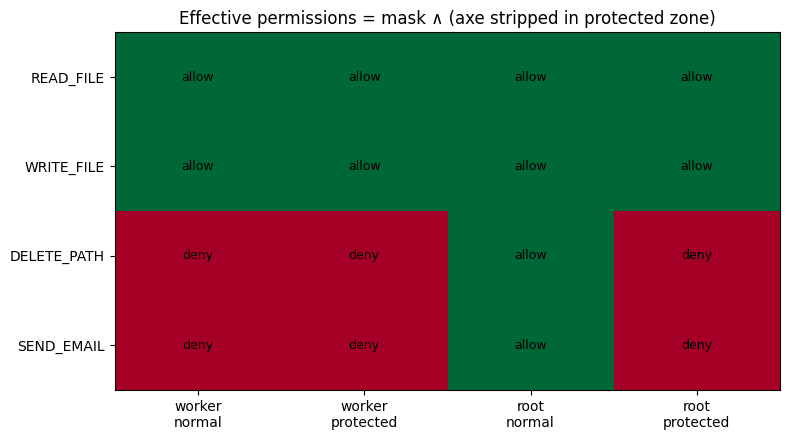

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Permission matrix: operations (rows) x (holder, zone) contexts (cols).
ops = [("READ_FILE", READ_FILE), ("WRITE_FILE", WRITE_FILE), ("DELETE_PATH", DELETE_PATH), ("SEND_EMAIL", SEND_EMAIL)]
contexts = [("worker\nnormal", worker, False), ("worker\nprotected", worker, True),
            ("root\nnormal", root, False), ("root\nprotected", root, True)]

grid = np.zeros((len(ops), len(contexts)))
for i, (_, bit) in enumerate(ops):
    for j, (_, tok, prot) in enumerate(contexts):
        grid[i, j] = 1.0 if permitted(bit, tok, in_protected_zone=prot) else 0.0

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(contexts))); ax.set_xticklabels([c[0] for c in contexts])
ax.set_yticks(range(len(ops)));      ax.set_yticklabels([o[0] for o in ops])
for i in range(len(ops)):
    for j in range(len(contexts)):
        ax.text(j, i, "allow" if grid[i, j] else "deny", ha="center", va="center", fontsize=9)
ax.set_title("Effective permissions = mask ∧ (axe stripped in protected zone)")
plt.tight_layout(); plt.show()

*The worker never gets the axe (DELETE/SEND_EMAIL stay red everywhere); root holds it in normal zones but loses it inside protected paths. The guarantee is structural — it doesn't depend on the model choosing well.*

## Exercises

In [8]:
# Exercise 1 (Warm-up): grant the worker one axe power, safely
# Task: re-attenuate the worker so it CAN SEND_EMAIL but still cannot DELETE_PATH,
#       then re-run the injected plan and confirm delete is still BLOCKED.
# Hint: change worker_request to include SEND_EMAIL and rebuild the token.

# YOUR CODE HERE

In [9]:
# Exercise 2 (Apply): enforce the lease inside permitted()
# Task: write permitted_leased(required, tok, reaper, ...) that ALSO returns False
#       when the token's lease is no longer valid in the reaper.
# Hint: combine reaper.is_valid(tok.lease_id, now=...) with the existing permitted().

# YOUR CODE HERE

In [10]:
# Exercise 3 (Extend): require the dual gate for every axe op in run_agent
# Task: extend run_agent so any axe-class step (needs & AXE_CLASS) is allowed only
#       if BOTH the capability check passes AND dual_gate(verdicts) is True.
# Hint: pass a verdicts list per step; rods skip the gate, axe ops require it.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
worker_request = WRITE_FILE | READ_FILE | SEND_EMAIL
worker = sign_token("worker", attenuate(root.mask, worker_request), "lease-worker", 0)
print(permitted(SEND_EMAIL, worker))   # True
print(permitted(DELETE_PATH, worker))  # still False
for tool, arg, status in run_agent(INJECTED_PLAN, worker, enforce=True):
    print(status, tool, arg)           # delete_path still BLOCKED

# Exercise 2
def permitted_leased(required, tok, reaper, *, in_protected_zone=False, now=None):
    if not reaper.is_valid(tok.lease_id, now=now):
        return False
    return permitted(required, tok, in_protected_zone=in_protected_zone, now=now)

# Exercise 3
def run_agent_gated(plan, token, verdicts_by_tool, *, enforce=True):
    log = []
    for step in plan:
        ok = permitted(step["needs"], token, in_protected_zone=zone_of(step["arg"])) if enforce else True
        if ok and (step["needs"] & AXE_CLASS):
            ok = dual_gate(verdicts_by_tool.get(step["tool"], []))
        log.append((step["tool"], step["arg"], "RAN" if ok else "BLOCKED"))
    return log
```
</details>

## Key Takeaways
- **Capabilities move the guarantee from the prompt to the runtime.** The agent can't do what its token doesn't grant — persuasion, jailbreaks, and injections can't manufacture a bit that isn't there.
- **Rods vs. axe.** Separate reversible from irreversible powers; default sub-agents to rods only, and make the axe expensive to obtain.
- **Attenuation shrinks blast radius down the tree.** `parent AND requested` means a delegate can only ever lose power — the invariant that makes multi-agent systems safe to scale.
- **Leases + zone policy + dual gate** are the belt-and-suspenders: grants expire on their own, protected zones strip the axe for everyone, and irreversible acts need two *uncorrelated* validators.
- This is the structural backstop to notebook 30's behavioural defenses: **detection can fail; capability boundaries hold anyway.**

## What's Next
Notebook 31 (MCP) introduces the standard protocol for sharing tools across agents and hosts — where capability scoping like this becomes a first-class concern the moment tools cross a trust boundary.